# Week 3: Can distillation help a small quantum classifier close the gap to a genome-wide teacher?

Week 2 showed a clear gap: the genome-wide logistic regression teacher reaches about 0.82 balanced accuracy,
while the best quantum kernel on 4 to 8 compressed features reaches about 0.72.

This notebook trains a small **variational quantum classifier (VQC)** on the same compressed features, in two ways:

- **VQC-CE**: trained on the hard labels only (the baseline).
- **VQC-KD**: trained on the hard labels plus the teacher's cross-fitted soft labels (knowledge distillation).

Both use the same circuit, initialisation, optimiser, epochs and folds, so the only difference is the training target.
The teacher's soft labels come from week 1 and were produced out-of-fold, so the student never sees
information from its own test fold.

Requirements: `pip install torch` (CPU is enough). The circuit is simulated exactly with a small PyTorch statevector
simulator written below, which is checked against Qiskit in section 2.

## 0. Configuration

In [1]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
WEEK1_DIR = Path("outputs/week1")
WEEK2_DIR = Path("outputs/week2")
OUT_DIR = Path("outputs/week3")
OUT_DIR.mkdir(parents=True, exist_ok=True)

QUBITS = [4, 6, 8]
N_FOLDS = 5
REPEAT = 0            # teacher soft labels exist for repeat 0

# Circuit and training settings. These are fixed in advance and are the same for CE and KD.
N_LAYERS = 3          # data re-uploading layers
EPOCHS = 150
LR = 0.03

# Distillation settings, fixed in advance (not tuned on test folds).
TEMPERATURE = 2.0     # softens the teacher's probabilities
ALPHA = 0.5           # weight on the distillation term; (1 - ALPHA) on hard-label cross-entropy

torch.set_num_threads(max(1, torch.get_num_threads()))
meta = json.load(open(WEEK1_DIR / "meta.json"))
CLASSES = meta["classes"]
K = len(CLASSES)
print("Classes:", CLASSES)

Classes: ['Basal', 'Her2', 'LumA', 'LumB', 'Normal']


## 1. A small statevector simulator in PyTorch

In [3]:
# State layout: tensor of shape (batch, 2, 2, ..., 2); axis q + 1 is qubit q.

def init_state(batch, n):
    s = torch.zeros((batch,) + (2,) * n, dtype=torch.complex64)
    s[(slice(None),) + (0,) * n] = 1.0
    return s

def apply_1q(state, U, q):
    # U has shape (2, 2) or (batch, 2, 2)
    s = state.movedim(q + 1, -1)
    if U.dim() == 2:
        s = s @ U.T
    else:
        shape = s.shape
        s = torch.einsum("bij,bkj->bki", U, s.reshape(shape[0], -1, 2)).reshape(shape)
    return s.movedim(-1, q + 1)

def ry(theta):
    c, s = torch.cos(theta / 2), torch.sin(theta / 2)
    U = torch.stack([torch.stack([c, -s], -1), torch.stack([s, c], -1)], -2)
    return U.to(torch.complex64)

def rz(phi):
    e = torch.exp(-0.5j * phi.to(torch.complex64))
    z = torch.zeros_like(e)
    return torch.stack([torch.stack([e, z], -1), torch.stack([z, e.conj()], -1)], -2)

def cnot(state, c, t):
    s0, s1 = state.select(c + 1, 0), state.select(c + 1, 1)
    t_ax = t + 1 if t < c else t        # target axis after removing the control axis
    return torch.stack([s0, s1.flip(t_ax)], dim=c + 1)

def expval_z(state, n):
    p = state.abs() ** 2
    out = []
    for q in range(n):
        pq = p.movedim(q + 1, 1).reshape(p.shape[0], 2, -1).sum(-1)
        out.append(pq[:, 0] - pq[:, 1])
    return torch.stack(out, dim=1)

## 2. The classifier, and a check against Qiskit

Each layer re-uploads the data with RY(x_i) on qubit i, then applies trainable RY and RZ rotations and a chain of CNOTs.
The <Z> expectation of each qubit goes into a small linear layer that outputs 5 class scores.
The same circuit is rebuilt in Qiskit with random parameters to confirm that the simulator is correct.

In [4]:
class VQC(nn.Module):
    def __init__(self, n_qubits, n_layers, n_classes, seed):
        super().__init__()
        g = torch.Generator().manual_seed(seed)
        self.n, self.L = n_qubits, n_layers
        self.theta = nn.Parameter(0.1 * torch.randn(n_layers, n_qubits, 2, generator=g))
        self.head = nn.Linear(n_qubits, n_classes)
        with torch.no_grad():
            self.head.weight.copy_(0.1 * torch.randn(n_classes, n_qubits, generator=g))
            self.head.bias.zero_()

    def circuit(self, x):
        s = init_state(x.shape[0], self.n)
        for l in range(self.L):
            for q in range(self.n):
                s = apply_1q(s, ry(x[:, q]), q)
                s = apply_1q(s, ry(self.theta[l, q, 0]), q)
                s = apply_1q(s, rz(self.theta[l, q, 1]), q)
            for q in range(self.n - 1):
                s = cnot(s, q, q + 1)
        return expval_z(s, self.n)

    def forward(self, x):
        return self.head(self.circuit(x))

def check_against_qiskit(n=4, L=2, seed=0):
    from qiskit import QuantumCircuit
    from qiskit.quantum_info import Statevector
    rng = np.random.default_rng(seed)
    x = rng.uniform(0, np.pi, n)
    m = VQC(n, L, K, seed)
    th = m.theta.detach().numpy()
    qc = QuantumCircuit(n)
    for l in range(L):
        for q in range(n):
            qc.ry(x[q], q); qc.ry(th[l, q, 0], q); qc.rz(th[l, q, 1], q)
        for q in range(n - 1):
            qc.cx(q, q + 1)
    sv = Statevector(qc)
    ref = np.array([sv.probabilities([q])[0] - sv.probabilities([q])[1] for q in range(n)])
    ours = m.circuit(torch.tensor(x[None], dtype=torch.float32)).detach().numpy()[0]
    return float(np.max(np.abs(ref - ours)))

err = check_against_qiskit()
print(f"Max difference from Qiskit: {err:.2e}")
assert err < 1e-4, "simulator does not match Qiskit"

Max difference from Qiskit: 3.37e-07


## 3. Training and metrics

The distillation loss follows the standard form:
ALPHA * T^2 * KL(teacher_T || student_T) + (1 - ALPHA) * weighted cross-entropy,
where both distributions are softened by temperature T. The teacher's saved probabilities are turned into
softened targets with p^(1/T), renormalised, which is the same as dividing its log-probabilities by T.
Class-weighted cross-entropy handles the class imbalance, as `class_weight="balanced"` did in weeks 1 and 2.

In [5]:
def score(y_true, proba):
    pred = proba.argmax(axis=1)
    return {"bal_acc": balanced_accuracy_score(y_true, pred),
            "macro_f1": f1_score(y_true, pred, average="macro"),
            "macro_auc": roc_auc_score(y_true, proba, multi_class="ovr",
                                       average="macro", labels=np.arange(K))}

def soften(p, T):
    p = np.clip(p, 1e-8, 1.0) ** (1.0 / T)
    return p / p.sum(axis=1, keepdims=True)

def train_vqc(Xtr, ytr, n_qubits, soft_tr=None, seed=SEED):
    torch.manual_seed(seed)
    model = VQC(n_qubits, N_LAYERS, K, seed)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    x = torch.tensor(Xtr, dtype=torch.float32)
    y = torch.tensor(ytr, dtype=torch.long)
    counts = np.bincount(ytr, minlength=K)
    w = torch.tensor(len(ytr) / (K * np.maximum(counts, 1)), dtype=torch.float32)
    q_soft = None if soft_tr is None else torch.tensor(soften(soft_tr, TEMPERATURE), dtype=torch.float32)
    history = []
    for epoch in range(EPOCHS):
        opt.zero_grad()
        logits = model(x)
        ce = F.cross_entropy(logits, y, weight=w)
        if q_soft is None:
            loss = ce
        else:
            log_p_student = F.log_softmax(logits / TEMPERATURE, dim=1)
            kd = F.kl_div(log_p_student, q_soft, reduction="batchmean") * TEMPERATURE ** 2
            loss = ALPHA * kd + (1 - ALPHA) * ce
        loss.backward()
        opt.step()
        history.append(float(loss))
    return model, history

def predict_proba(model, X):
    with torch.no_grad():
        return F.softmax(model(torch.tensor(X, dtype=torch.float32)), dim=1).numpy()

## 4. Run CE and KD for every qubit count and fold

In [6]:
teacher = np.load(WEEK1_DIR / "teacher_soft_labels.npz")
rows, curves = [], {}
t_start = time.time()
for q in QUBITS:
    data = np.load(WEEK1_DIR / f"compressed_pca{q}.npz")
    for f in range(N_FOLDS):
        key = f"r{REPEAT}_f{f}"
        Xtr, Xte = data[f"{key}_Xtr"], data[f"{key}_Xte"]
        ytr, yte = data[f"{key}_ytr"], data[f"{key}_yte"]
        # the teacher's soft labels must line up with the same training samples, in the same order
        assert np.array_equal(teacher[f"{key}_tr_idx"], data[f"{key}_tr_idx"]), "sample order mismatch"
        soft_tr = teacher[f"{key}_soft_tr"]

        if q == QUBITS[0]:
            rows.append({"model": "Teacher (genome-wide LR)", "qubits": np.nan, "fold": f,
                         **score(yte, teacher[f"{key}_proba_te_eval_only"]), "runtime_s": np.nan})

        for mode, soft in [("VQC-CE", None), ("VQC-KD", soft_tr)]:
            t0 = time.time()
            model, hist = train_vqc(Xtr, ytr, q, soft)
            rows.append({"model": mode, "qubits": q, "fold": f,
                         **score(yte, predict_proba(model, Xte)), "runtime_s": time.time() - t0})
            if f == 0:
                curves[(q, mode)] = hist
        print(f"{q} qubits, fold {f} done ({time.time() - t_start:.0f}s elapsed)")

results = pd.DataFrame(rows)
results.to_csv(OUT_DIR / "results_per_fold.csv", index=False)

4 qubits, fold 0 done (9s elapsed)
4 qubits, fold 1 done (19s elapsed)
4 qubits, fold 2 done (27s elapsed)
4 qubits, fold 3 done (36s elapsed)
4 qubits, fold 4 done (55s elapsed)
6 qubits, fold 0 done (96s elapsed)
6 qubits, fold 1 done (136s elapsed)
6 qubits, fold 2 done (157s elapsed)
6 qubits, fold 3 done (198s elapsed)
6 qubits, fold 4 done (236s elapsed)
8 qubits, fold 0 done (304s elapsed)
8 qubits, fold 1 done (378s elapsed)
8 qubits, fold 2 done (453s elapsed)
8 qubits, fold 3 done (528s elapsed)
8 qubits, fold 4 done (603s elapsed)


## 5. Summary, with week 2 references

The week 2 rows are copied from `outputs/week2/results_per_fold.csv` for comparison (same folds, same inputs):
the best quantum kernel at bandwidth 0.1, the RBF-SVM and logistic regression.

In [7]:
summary = (results.groupby(["qubits", "model"], dropna=False)[["bal_acc", "macro_f1", "macro_auc"]]
                  .agg(["mean", "std"]).round(3))
summary.to_csv(OUT_DIR / "summary.csv")
display(summary)

# Paired comparison: KD minus CE on the same fold
paired = results[results.model.isin(["VQC-CE", "VQC-KD"])].pivot_table(
    index=["qubits", "fold"], columns="model", values="bal_acc")
paired["KD_minus_CE"] = paired["VQC-KD"] - paired["VQC-CE"]
teacher_mean = results.loc[results.model.str.startswith("Teacher"), "bal_acc"].mean()
gap = paired.groupby("qubits").agg(CE=("VQC-CE", "mean"), KD=("VQC-KD", "mean"),
                                   KD_minus_CE=("KD_minus_CE", "mean"),
                                   folds_KD_better=("KD_minus_CE", lambda s: int((s > 0).sum())))
gap["teacher"] = teacher_mean
gap["share_of_gap_closed"] = (gap["KD"] - gap["CE"]) / (gap["teacher"] - gap["CE"])
gap = gap.round(3)
gap.to_csv(OUT_DIR / "distillation_gap.csv")
display(gap)

w2_path = WEEK2_DIR / "results_per_fold.csv"
if w2_path.exists():
    w2 = pd.read_csv(w2_path)
    if "config" not in w2.columns:
        w2["config"] = np.where(w2["model"] == "QSVM", "QSVM " + w2["kernel"], w2["model"])
    keep = w2["config"].isin(["LogReg_L2", "SVM_RBF"]) | w2["config"].str.contains("bw0.1", regex=False)
    display(w2[keep].groupby(["qubits", "config"])["bal_acc"].agg(["mean", "std"]).round(3))

bal_acc        macro_f1        macro_auc  \
                                   mean    std     mean    std      mean   
qubits model                                                               
4.0    VQC-CE                     0.746  0.056    0.671  0.047     0.926   
       VQC-KD                     0.665  0.052    0.674  0.040     0.918   
6.0    VQC-CE                     0.725  0.064    0.654  0.034     0.929   
       VQC-KD                     0.652  0.075    0.653  0.059     0.935   
8.0    VQC-CE                     0.745  0.075    0.671  0.036     0.926   
       VQC-KD                     0.666  0.064    0.682  0.066     0.938   
NaN    Teacher (genome-wide LR)   0.827  0.063    0.833  0.066     0.985   

                                        
                                   std  
qubits model                            
4.0    VQC-CE                    0.022  
       VQC-KD                    0.035  
6.0    VQC-CE                    0.013  
       VQC-KD                    0.021  
8.0    VQC-CE                    0.023  
       VQC-KD                    0.021  
NaN    Teacher (genome-wide LR)  0.006

,CE,KD,KD_minus_CE,folds_KD_better,teacher,share_of_gap_closed
qubits,,,,,,
4.0,0.746,0.665,-0.081,1,0.827,-1.010
6.0,0.725,0.652,-0.073,1,0.827,-0.711
8.0,0.745,0.666,-0.079,1,0.827,-0.964


mean    std
qubits config                           
4      LogReg_L2            0.825  0.045
       QSVM ZZ-reps1-bw0.1  0.693  0.040
       QSVM ZZ-reps2-bw0.1  0.712  0.033
       SVM_RBF              0.729  0.034
6      LogReg_L2            0.813  0.062
       QSVM ZZ-reps1-bw0.1  0.725  0.039
       QSVM ZZ-reps2-bw0.1  0.669  0.032
       SVM_RBF              0.700  0.037
8      LogReg_L2            0.809  0.058
       QSVM ZZ-reps1-bw0.1  0.696  0.065
       QSVM ZZ-reps2-bw0.1  0.718  0.052
       SVM_RBF              0.725  0.018

## 6. Figures

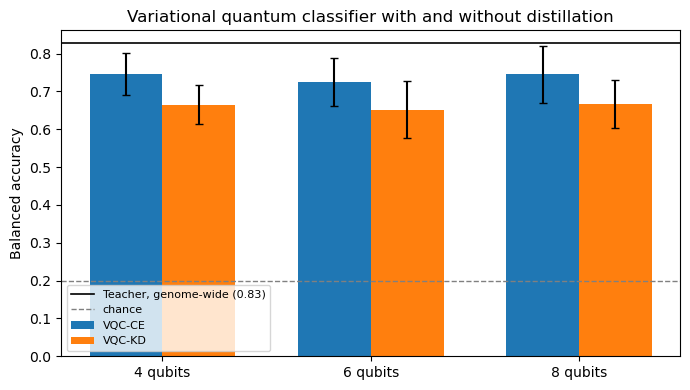

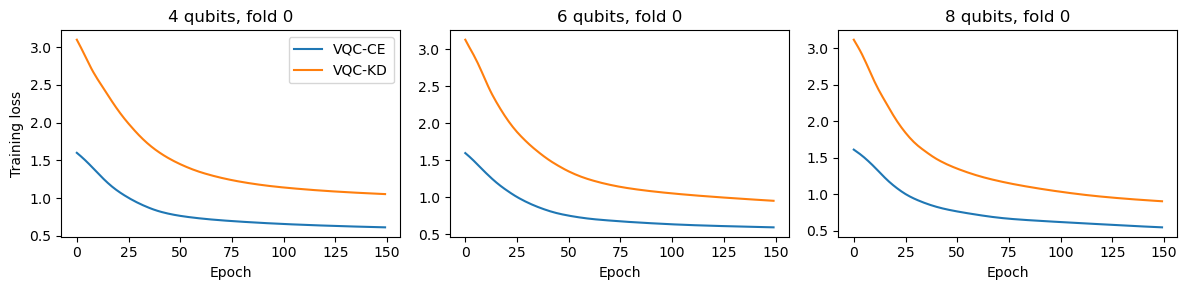

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(QUBITS))
for j, mode in enumerate(["VQC-CE", "VQC-KD"]):
    sub = results[results.model == mode].groupby("qubits")["bal_acc"].agg(["mean", "std"]).loc[QUBITS]
    ax.bar(x + (j - 0.5) * 0.35, sub["mean"], 0.35, yerr=sub["std"], capsize=3, label=mode)
ax.axhline(teacher_mean, ls="-", c="black", lw=1.2, label=f"Teacher, genome-wide ({teacher_mean:.2f})")
ax.axhline(1 / K, ls="--", c="gray", lw=1, label="chance")
ax.set_xticks(x)
ax.set_xticklabels([f"{q} qubits" for q in QUBITS])
ax.set_ylabel("Balanced accuracy")
ax.set_title("Variational quantum classifier with and without distillation")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "distillation_results.png", dpi=200)
plt.show()

fig, axes = plt.subplots(1, len(QUBITS), figsize=(4 * len(QUBITS), 3), sharey=False)
for ax, q in zip(axes, QUBITS):
    for mode in ["VQC-CE", "VQC-KD"]:
        ax.plot(curves[(q, mode)], label=mode)
    ax.set_title(f"{q} qubits, fold 0")
    ax.set_xlabel("Epoch")
axes[0].set_ylabel("Training loss")
axes[0].legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "training_curves.png", dpi=200)
plt.show()

## 7. How to read the results

- **KD_minus_CE** is the average paired improvement on the same folds. `folds_KD_better` counts how many of the 5 folds improved.
  With 5 folds, treat a small average difference with fewer than 4 of 5 folds improving as no clear effect.
- **share_of_gap_closed** is the fraction of the CE-to-teacher gap that distillation recovered.
- The two losses are on different scales (KD adds a KL term), so compare the curves' shapes, not their heights.
  Both should flatten by the last epochs. If they are still falling steeply, increase `EPOCHS` for both and re-run.
- Temperature and alpha were fixed in advance. If you try other values, report all of them, not only the best.

Files in `outputs/week3/`: `results_per_fold.csv`, `summary.csv`, `distillation_gap.csv`, `distillation_results.png`, `training_curves.png`.